# QuantumCircuit.jl Phase 2 Tunable Sweep Walkthrough

**Audience**
- Julia users who already know the Phase 1 workflow and want to use tunable devices and sweep analysis.

**Prerequisites**
- Basic Julia syntax.
- Familiarity with `CompositeSystem`, `spectrum`, and `transition_frequencies`.
- Basic intuition for reduced flux and SQUID tunability.

**What you will learn**
- How `flux` and asymmetry factor `d` change the effective Josephson energy of a flux-tunable SQUID element.
- Which parameters practitioners usually track when modeling a flux-tunable component.
- How to define a `TunableTransmon` and build a flux sweep.
- How to summarize a sweep with `transition_curve`, `anharmonicity_curve`, `minimum_gap`, and `sweep_summary`.
- How to run a coupling sweep with the same `SweepSpec` interface.
- How to inspect the updated model stored inside each `SpectrumResult`.

This notebook keeps the original Phase 2 workflow, but adds a short concept section up front so the later sweeps are easier to interpret physically.


## Outline

1. Activate the local package environment and plotting helpers.
2. Define a tunable subsystem and run a small flux sweep.
3. Visualize how asymmetry factor `d` changes `EJ_eff(Φ, d)`.
4. Review the parameters people usually track for flux-tunable components.
5. Connect the Josephson-energy picture to an approximate transmon frequency scale.
6. Summarize the sweep with the current Analysis helpers.
7. Run a coupling sweep in a coupled system.
8. Inspect the applied sweep parameters directly from the results.
9. Review pitfalls and try a small exercise.


In [2]:
using Pkg

function find_repo_root(start::AbstractString)
    candidates = [
        normpath(start),
        normpath(joinpath(start, "..")),
        normpath(joinpath(start, "..", "..")),
    ]

    for candidate in unique(candidates)
        project_toml = joinpath(candidate, "Project.toml")
        if isfile(project_toml)
            content = read(project_toml, String)
            occursin("QuantumCircuit", content) && return candidate
        end
    end

    error("Could not find the QuantumCircuit.jl project root. Start Jupyter from the repository or open the notebook from inside it.")
end

project_root = find_repo_root(pwd())
Pkg.activate(project_root)
Pkg.instantiate()

using QuantumCircuit
using CairoMakie

include(joinpath(project_root, "output", "jupyter-notebook", "makie_helpers.jl"))
activate_notebook_theme!()


  Activating project at `~/Research/20_Projects/QuantumCircuit.jl`


## Step 1 - Define a tunable subsystem and flux sweep

Phase 2 keeps the same `CompositeSystem` entry point but adds tunable subsystem types. We start by creating one tunable transmon and a small flux sweep that will be reused later.

**Unit convention**
- `EJmax`, `EC`, resonator `ω`, and coupling `g` should use the same frequency unit.
- This walkthrough uses `GHz`, so reported energies and transition frequencies are also in `GHz`.
- `flux` is dimensionless reduced flux `Phi/Phi0`.
- `asymmetry` is the dimensionless SQUID asymmetry factor `d`.


In [3]:
tq = TunableTransmon(:tq; EJmax = 20.0, EC = 0.25, flux = 0.0, asymmetry = 0.05, ncut = 6)
tunable_sys = CompositeSystem(tq)

flux_values = [0.0, 0.10, 0.20, 0.30]
flux_sweep = SweepSpec(:tq, :flux, flux_values; levels = 4)
flux_result = simulate_sweep(tunable_sys, flux_sweep)

(
    subsystem_names = subsystem_names(tunable_sys),
    sweep_values = flux_result.values,
    first_spectrum = flux_result.spectra[1].energies,
)


(subsystem_names = [:tq], sweep_values = [0.0, 0.1, 0.2, 0.3], first_spectrum = [0.0, 6.074555320336759, 11.899110640673522, 17.473665961010273])

## Step 2 - Visualize how asymmetry factor `d` changes the effective Josephson energy

For the flux-tunable SQUID model used by `TunableTransmon` and `TunableCoupler`, the effective Josephson energy is

`EJ_eff(Φ, d) = EJmax * sqrt(cospi(Φ)^2 + d^2 * sinpi(Φ)^2)`.

The key qualitative point is simple:
- `d = 0` gives the deepest modulation and can drive the half-flux point close to zero Josephson energy.
- `d > 0` lifts that minimum, so the half-flux region becomes less singular and easier to keep inside the reduced model.
- Near the sweet spot `Φ = 0`, different `d` values often look similar, which is why asymmetry can be weakly identified from parked-point data alone.


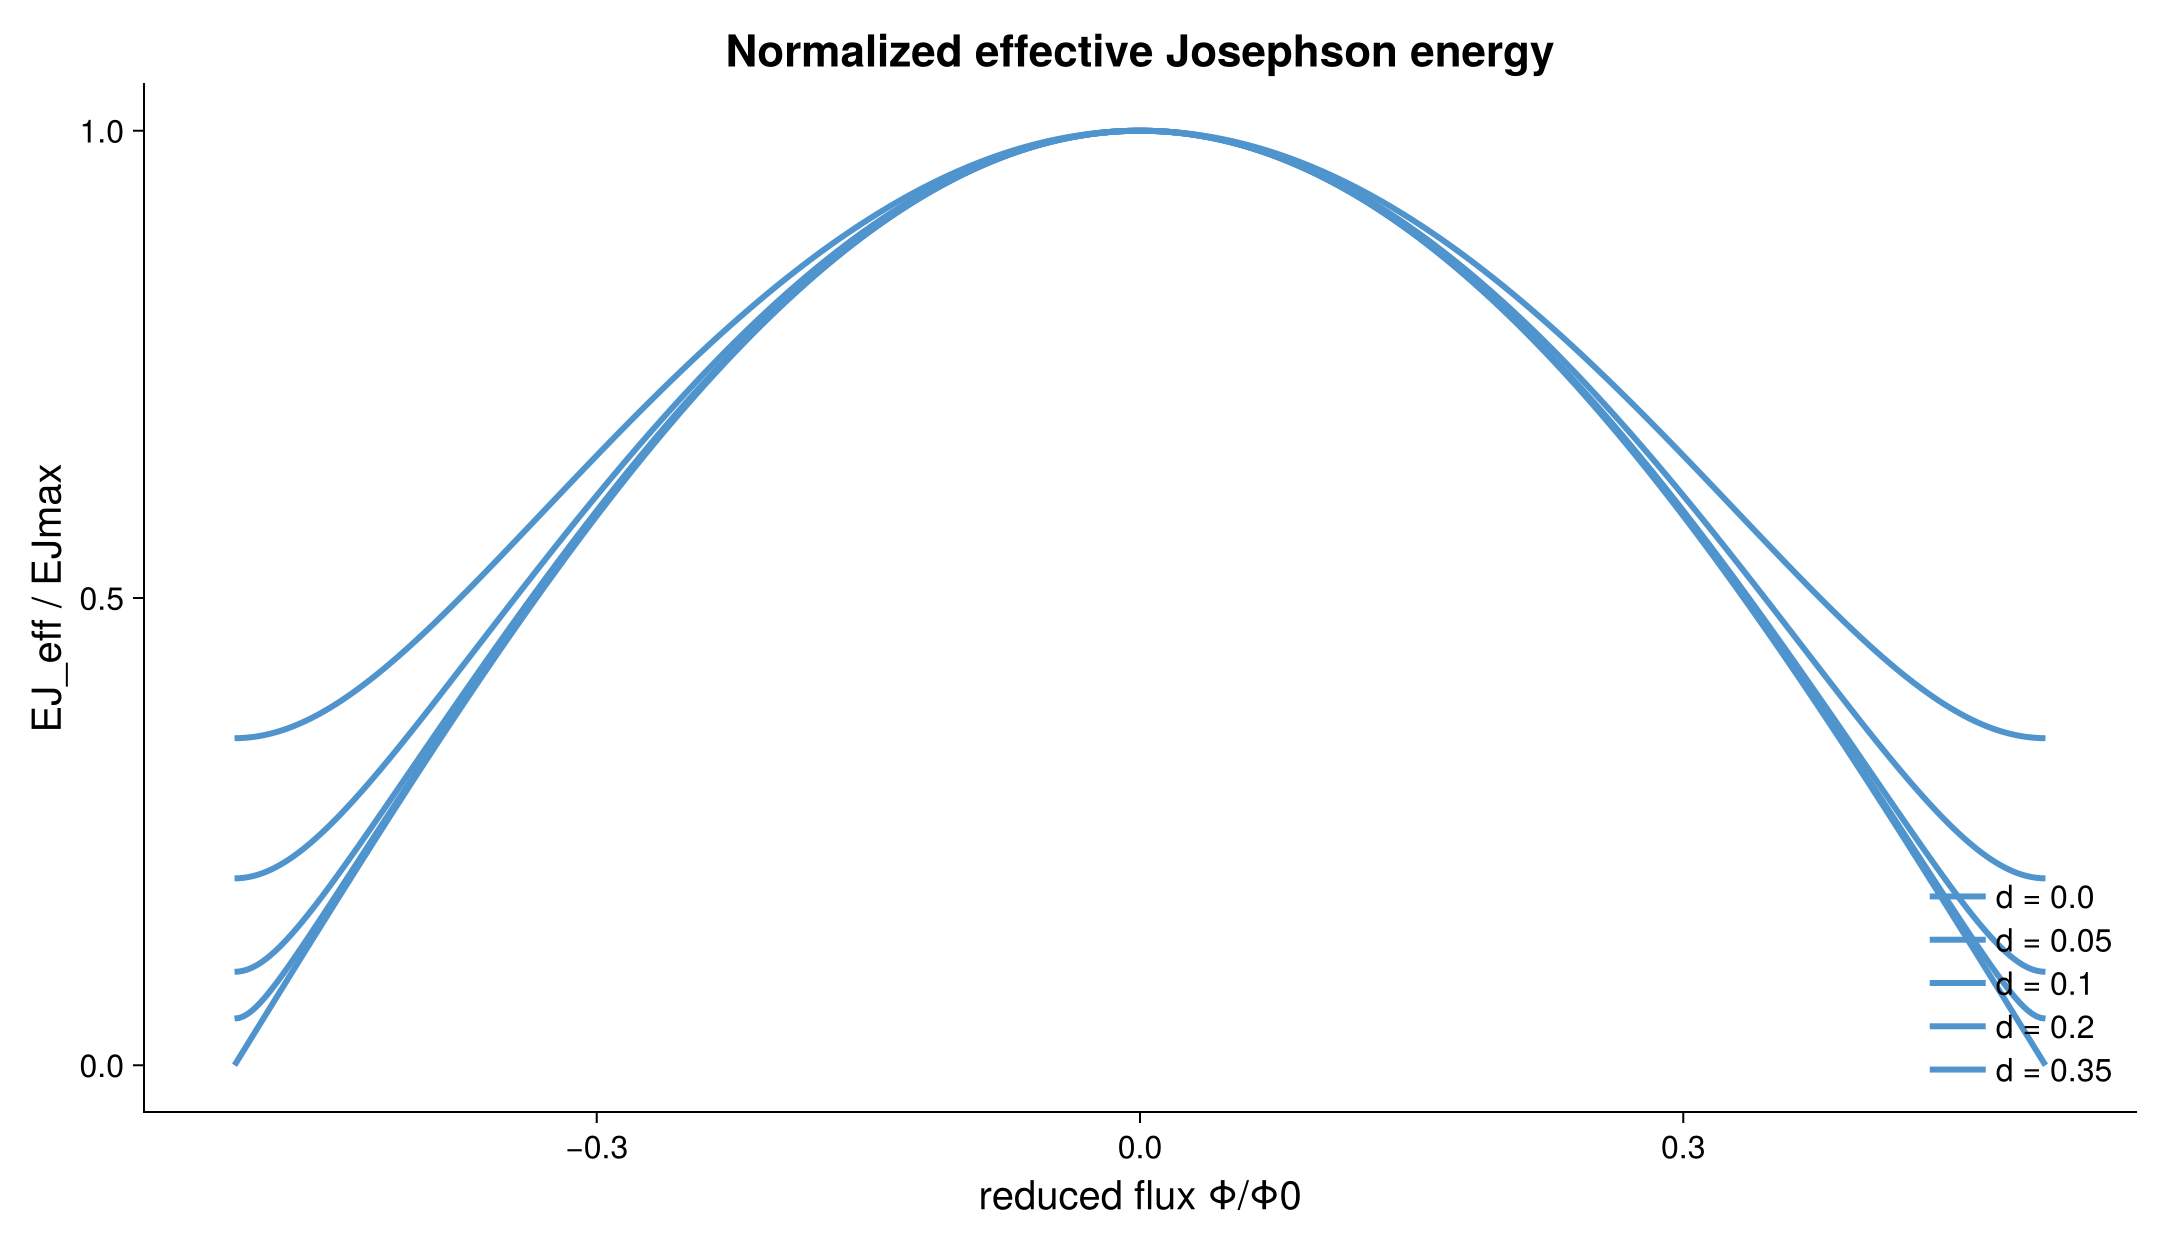

In [4]:
effective_josephson_energy(EJmax, flux, d) =
    EJmax * sqrt(cospi(flux)^2 + (d * sinpi(flux))^2)

approx_transmon_f01(EJ_eff, EC) = sqrt(8 * EJ_eff * EC) - EC

function josephson_energy_curves(EJmax, flux_grid, d_values)
    return [
        (
            x = flux_grid,
            y = [effective_josephson_energy(EJmax, flux, d) / EJmax for flux in flux_grid],
            label = "d = $(round(d, digits = 2))",
        ) for d in d_values
    ]
end

flux_grid = collect(range(-0.5, 0.5; length = 401))
d_values = [0.0, 0.05, 0.10, 0.20, 0.35]
normalized_curves = josephson_energy_curves(20.0, flux_grid, d_values)

normalized_ej_fig = line_figure(
    normalized_curves;
    title = "Normalized effective Josephson energy",
    xlabel = "reduced flux Φ/Φ0",
    ylabel = "EJ_eff / EJmax",
    size = NOTEBOOK_WIDE,
    legend_position = :rb,
)

normalized_ej_fig


## Step 3 - What people usually track for a flux-tunable component

실무에서 flux-tunable component를 볼 때는 보통 아래 parameter들을 함께 봅니다.

**Device / intrinsic parameters**
- `EJmax`: SQUID가 가질 수 있는 최대 Josephson energy scale입니다.
- `EC`: charging energy이고, transmon의 anharmonicity와 직접 연결됩니다.
- `d` (`asymmetry`): junction 비대칭을 요약하는 무차원 parameter입니다. half-flux minimum이 얼마나 lift되는지를 주로 결정합니다.
- `ng`: offset charge입니다. transmon regime에서는 민감도가 작을 수 있지만 exact circuit model에서는 여전히 parameter로 남습니다.

**Operating-point parameters**
- `flux`: 현재 bias point입니다.
- parked flux / sweet spot: 보통 `flux ≈ 0` 근처를 의미하고, 작은 flux noise에 대해 1차 민감도가 낮습니다.
- flux sensitivity: `dω/dΦ` 또는 그에 준하는 민감도입니다. gate tuning과 noise sensitivity를 같이 생각할 때 중요합니다.

**Spectral observables**
- `f01`: 가장 먼저 맞추는 전이 주파수입니다.
- anharmonicity `α`: leakage와 control selectivity를 볼 때 중요합니다.

**Numerical / modeling parameters**
- `ncut`: effective Duffing truncation이나 subsystem Hilbert dimension을 정하는 값입니다.
- `charge_cutoff`: exact circuit Hamiltonian에서 charge basis truncation을 정하는 값입니다.

**Coupled-system context**
- `g`, `G`: flux-tunable element를 다른 모드와 연결할 때는 local parameter만으로 충분하지 않고 coupling parameter까지 같이 봐야 합니다. 이 notebook의 뒤쪽 coupling sweep이 그 최소 예시입니다.


## Step 4 - Connect the Josephson-energy picture to an approximate frequency scale

정규화 plot은 shape을 보기엔 좋지만, 실제 modeling에서는 absolute energy scale도 같이 보는 편이 편합니다. 아래 예시는 toy transmon parameter를 고정하고 `EJ_eff(Φ)`와 근사 `ω01 ≈ sqrt(8 E_J_eff E_C) - E_C`를 나란히 그린 것입니다.

이 `ω01` 식은 정확한 circuit diagonalization 결과가 아니라 transmon limit의 빠른 intuition용 근사입니다. 즉, shape를 읽는 용도로 쓰고 최종 수치는 실제 `simulate_sweep(...)` 또는 exact spectrum으로 다시 확인해야 합니다.


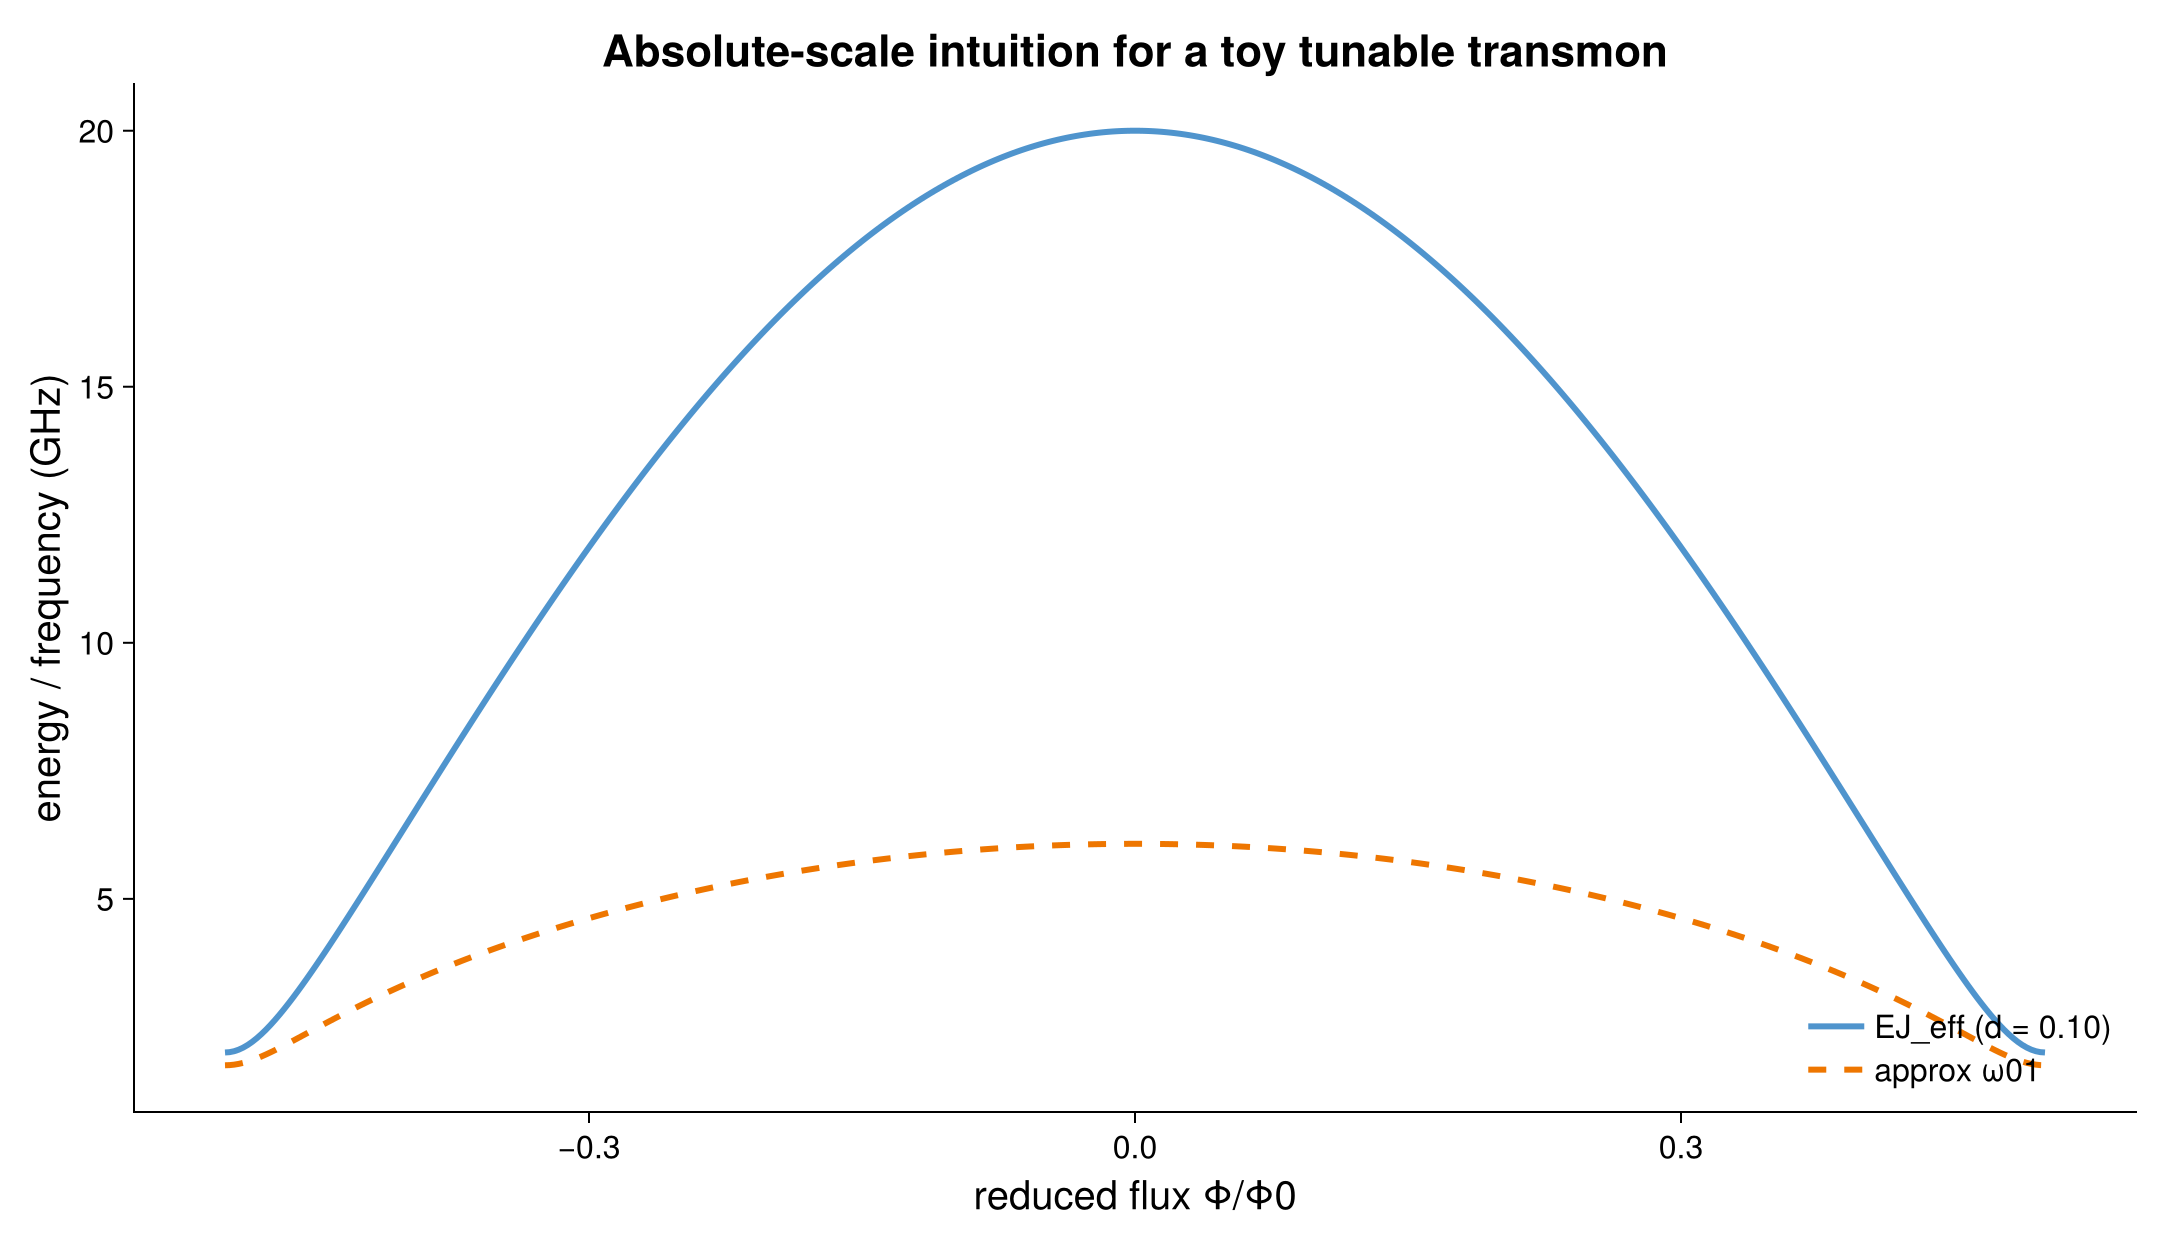

In [5]:
toy_EJmax = 20.0
toy_EC = 0.25
toy_d = 0.10

toy_EJ_curve = [effective_josephson_energy(toy_EJmax, flux, toy_d) for flux in flux_grid]
toy_f01_curve = [approx_transmon_f01(EJ_eff, toy_EC) for EJ_eff in toy_EJ_curve]

absolute_fig = Figure(size = NOTEBOOK_WIDE)
ax_ej = Axis(
    absolute_fig[1, 1];
    title = "Absolute-scale intuition for a toy tunable transmon",
    xlabel = "reduced flux Φ/Φ0",
    ylabel = "energy / frequency (GHz)",
)
lines!(ax_ej, flux_grid, toy_EJ_curve; color = :steelblue3, label = "EJ_eff (d = 0.10)")
lines!(ax_ej, flux_grid, toy_f01_curve; color = :darkorange2, linestyle = :dash, label = "approx ω01")
axislegend(ax_ej; position = :rb)
absolute_fig


## Step 5 - Summarize the sweep with Analysis helpers

이제 앞에서 본 `EJ_eff(Φ, d)` intuition을 실제 sweep 결과와 연결합니다. The current Analysis layer is result-driven, so the helpers read `SpectrumResult` and `SweepResult` directly instead of rebuilding Hamiltonians or rerunning solvers.


In [6]:
ω01_curve = transition_curve(flux_result)
alpha_curve = anharmonicity_curve(flux_result)
gap = minimum_gap(flux_result)
summary = sweep_summary(flux_result)

(
    label = ω01_curve.label,
    flux_values = summary.values,
    ω01 = ω01_curve.data,
    α = alpha_curve.data,
    minimum_gap = gap,
)


(label = :transition_01, flux_values = [0.0, 0.1, 0.2, 0.3], ω01 = [6.074555320336759, 5.9182477743678135, 5.440520651422999, 4.604587535975373], α = [-0.24999999999999645, -0.24999999999999822, -0.24999999999999822, -0.24999999999999822], minimum_gap = (gap = 4.604587535975373, sweep_value = 0.3, index = 4, level_pair = (1, 2)))

## Step 6 - Sweep a coupling parameter in a coupled system

The same `SweepSpec` entry point also works for couplings. Here the sweep target is identified by the two subsystem names attached to the coupling.


In [7]:
q1 = Transmon(:q1; EJ = 20.0, EC = 0.25, ncut = 5)
r1 = Resonator(:r1; ω = 6.8, dim = 4)

coupled_sys = CompositeSystem(
    q1,
    r1,
    CapacitiveCoupling(:q1, :r1; g = 0.02),
)

g_values = [0.02, 0.08, 0.14]
g_sweep = SweepSpec(:q1, :r1, :g, g_values; levels = 5)
g_result = simulate_sweep(coupled_sys, g_sweep)
g_curve = transition_curve(g_result)
g_summary = sweep_summary(g_result)

(
    coupling_values = g_summary.values,
    ω01 = g_curve.data,
    weakest_coupling_spectrum = g_result.spectra[1].energies,
)


(coupling_values = [0.02, 0.08, 0.14], ω01 = [6.074004352846019, 6.065837899489844, 6.0484750163850265], weakest_coupling_spectrum = [0.0, 6.074004352846019, 6.800550967490739, 11.898290795844863, 12.874273352821513])

## Step 7 - Inspect the updated model stored in each result

Each `SpectrumResult` keeps the model that produced it. This makes it easy to verify which parameter value was actually applied at a given sweep point.


In [8]:
(
    swept_flux = flux_result.spectra[3].model.system.subsystems[1].flux,
    swept_coupling = g_result.spectra[3].model.system.couplings[1].g,
    flux_curve_label = ω01_curve.label,
    coupling_curve_label = g_curve.label,
)


(swept_flux = 0.2, swept_coupling = 0.14, flux_curve_label = :transition_01, coupling_curve_label = :transition_01)

## Pitfalls and Current Limits

**Common pitfall**
- Sweeping flux all the way to `0.5` with `d = 0` can drive the effective Josephson energy near zero. In the normalized CairoMakie plot above, this is exactly the curve that develops the deepest half-flux minimum.

**Current model assumption**
- The tunable path still uses a Duffing-style approximation with a SQUID effective `EJ`, so very small `EJ_eff` regions should be treated with care.

**Practical reading**
- Treat this notebook as a solid Phase 2 workflow and intuition builder, not yet as a full circuit-quantization or pulse-calibrated dynamics workflow.

**Where to go next**
- If you want the current paper-linked baseline used in this repo, inspect `output/renger2026/paper_local_priors.toml` together with `src/Analysis/Renger2026.jl`.


In [9]:
problematic = TunableTransmon(:bad; EJmax = 20.0, EC = 0.25, flux = 0.5, asymmetry = 0.0, ncut = 6)

try
    hamiltonian(CompositeSystem(problematic))
catch err
    sprint(showerror, err)
end


"ArgumentError: Duffing approximation for bad requires a positive local frequency; choose parameters with larger effective EJ."

## Exercise

이번에는 `d`를 중심으로 바꿔 보세요.

1. `d_values`에 `0.5`를 추가해서 half-flux minimum이 얼마나 더 lift되는지 보세요.
2. `toy_d`를 `0.0`, `0.05`, `0.2`로 바꿔 absolute-scale plot의 `approx ω01` minimum이 어떻게 달라지는지 비교해 보세요.
3. 그 다음 `exercise_tq`의 `asymmetry`를 바꿔 실제 `transition_curve`와 intuition plot이 같은 방향으로 움직이는지 확인해 보세요.

Before running the next cell, predict which `d` value will give the shallowest half-flux dip.


In [10]:
exercise_d = 0.2
exercise_tq = TunableTransmon(:tq; EJmax = 20.0, EC = 0.25, flux = 0.0, asymmetry = exercise_d, ncut = 6)
exercise_sys = CompositeSystem(exercise_tq)
exercise_sweep = SweepSpec(:tq, :flux, [0.0, 0.15, 0.30, 0.45]; levels = 4)
exercise_result = simulate_sweep(exercise_sys, exercise_sweep)

exercise_transition = transition_curve(exercise_result).data
normalized_transition = exercise_transition ./ maximum(exercise_transition)
normalized_ej = [effective_josephson_energy(20.0, flux, exercise_d) / 20.0 for flux in flux_grid]
exercise_fig = line_figure(
    [
        (x = flux_grid, y = normalized_ej, label = "normalized EJ_eff", color = :seagreen4),
        (x = exercise_result.values, y = normalized_transition, label = "normalized ω01", color = :darkorange2, linestyle = :dash),
    ];
    title = "Exercise: compare normalized intuition and simulated spectrum",
    xlabel = "reduced flux Φ/Φ0",
    ylabel = "normalized value",
    size = NOTEBOOK_WIDE,
    legend_position = :rb,
)

(
    asymmetry = exercise_tq.asymmetry,
    ω01 = exercise_transition,
    minimum_gap = minimum_gap(exercise_result),
    figure = exercise_fig,
)


(asymmetry = 0.2, ω01 = [6.074555320336759, 5.735385433041085, 4.68821405117471, 2.9247624794395577], minimum_gap = (gap = 2.9247624794395577, sweep_value = 0.45, index = 4, level_pair = (1, 2)), figure = Scene(2 children, 0 plots))